# ANN Part 2: Neural Networks in NumPy and PyTorch

In this lab, you will build dense neural networks on the MNIST dataset **twice**:

1. **Using NumPy only** so that you can demonstrate your understanding of the forward pass, parameter representation, and core training computations.
2. **Using a deep learning framework (PyTorch)** so that you can compare your manual implementation with a standard library-based workflow.

For every major exercise, complete the **NumPy version first**, then complete the **PyTorch version**. At the end of the notebook, you must prepare a **summary table** comparing your implementations, settings, and results.


## Load the data and create train-test splits

In [1]:
# Auto-setup when running on Google Colab
if 'google.colab' in str(get_ipython()):
    !pip install openml
    !pip install pytorch_lightning

# General imports
%matplotlib inline
import numpy as np
import pandas as pd
import openml as oml
import matplotlib.pyplot as plt
import pytorch_lightning as pl
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms

/tmp/ipykernel_28754/3841004139.py:3: FutureWarning: Support for `dataset_format='array'` will be removed in 0.15,start using `dataset_format='dataframe' to ensure your code will continue to work. You can use the dataframe's `to_numpy` function to continue using numpy arrays.
  X, y, _, _ = mnist.get_data(target=mnist.default_target_attribute, dataset_format='array');


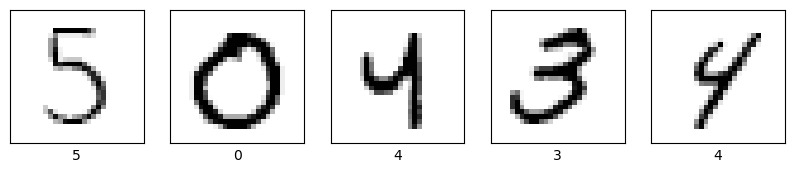

In [2]:
# Download MNIST data. Takes a while the first time.
mnist = oml.datasets.get_dataset(554)
X, y, _, _ = mnist.get_data(target=mnist.default_target_attribute, dataset_format='array');
X = X.reshape(70000, 28, 28)

# Take some random examples
from random import randint
fig, axes = plt.subplots(1, 5,  figsize=(10, 5))
for i in range(5):
    n = randint(0,70000)
    axes[i].imshow(X[n], cmap=plt.cm.gray_r)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_xlabel("{}".format(y[n]))
plt.show();

In [3]:
# For MNIST, there exists a predefined stratified train-test split of 60000-10000. We therefore don't shuffle or stratify here.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=60000, random_state=0)

## Exercise 1: Preprocessing in NumPy, then in PyTorch

Complete the preprocessing pipeline in **two stages**:

### Part A. NumPy
* Normalize the data: map each feature value from its current representation (an integer between 0 and 255) to a floating-point value between 0 and 1.0.
* Use the given train-test split of 60,000 training examples and 10,000 testing examples.
* Flatten each image from shape `(28, 28)` to a vector of shape `(784,)`.
* Ensure your NumPy arrays have appropriate dtypes for the features and targets.

### Part B. PyTorch
* Starting from your processed NumPy arrays, convert the data to PyTorch tensors.
* Create a `TensorDataset` for the training data and another one for the testing data.

Your goal in this exercise is to show that you can preprocess the same dataset both manually with NumPy and in a format that can be consumed by a neural network framework.


In [4]:
# Exercise 1A - NumPy preprocessing

X_train_np = X_train.reshape(X_train.shape[0], -1).astype(np.float32) / 255.0
X_test_np  = X_test.reshape(X_test.shape[0],  -1).astype(np.float32) / 255.0

y_train_np = y_train.astype(np.int64)
y_test_np  = y_test.astype(np.int64)

print(f'X_train_np shape: {X_train_np.shape}, dtype: {X_train_np.dtype}')
print(f'X_test_np  shape: {X_test_np.shape},  dtype: {X_test_np.dtype}')
print(f'y_train_np shape: {y_train_np.shape}, dtype: {y_train_np.dtype}')
print(f'y_test_np  shape: {y_test_np.shape},  dtype: {y_test_np.dtype}')
print(f'Feature range: [{X_train_np.min():.1f}, {X_train_np.max():.1f}]')

X_train_np shape: (60000, 784), dtype: float32
X_test_np  shape: (10000, 784),  dtype: float32
y_train_np shape: (60000,), dtype: int64
y_test_np  shape: (10000,),  dtype: int64
Feature range: [0.0, 1.0]


In [5]:
# Exercise 1B - Convert the processed NumPy arrays to PyTorch tensors and datasets

X_train_tensor = torch.tensor(X_train_np)
X_test_tensor  = torch.tensor(X_test_np)
y_train_tensor = torch.tensor(y_train_np)
y_test_tensor  = torch.tensor(y_test_np)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

print(f'X_train_tensor: {X_train_tensor.shape}, dtype: {X_train_tensor.dtype}')
print(f'X_test_tensor:  {X_test_tensor.shape},  dtype: {X_test_tensor.dtype}')
print(f'y_train_tensor: {y_train_tensor.shape}, dtype: {y_train_tensor.dtype}')
print(f'y_test_tensor:  {y_test_tensor.shape},  dtype: {y_test_tensor.dtype}')
print(f'train_dataset length: {len(train_dataset)}')
print(f'test_dataset  length: {len(test_dataset)}')


X_train_tensor: torch.Size([60000, 784]), dtype: torch.float32
X_test_tensor:  torch.Size([10000, 784]),  dtype: torch.float32
y_train_tensor: torch.Size([60000]), dtype: torch.int64
y_test_tensor:  torch.Size([10000]),  dtype: torch.int64
train_dataset length: 60000
test_dataset  length: 10000


## Exercise 2: Create the model in NumPy, then in PyTorch

In this exercise, you will define the neural network architecture in **two forms**.

### Part A. NumPy
Implement the building blocks of a two-layer neural network using NumPy. At minimum, define:
* a parameter initialization function
* a forward-pass function
* the activation functions you need

Represent the parameters explicitly (for example, weight matrices and bias vectors).

### Part B. PyTorch
Implement a `create_model` function which defines the topology of the deep neural network, specifying the following:
* The number of layers in the neural network: use **2 dense layers** for now (one hidden layer and one output layer).
* The number of nodes in each layer: these should be parameters of your function.
* Any regularization layers. Add at least one dropout layer.

Consider:
* What should be the shape of the input layer?
* Which output activation or output interpretation is appropriate for a **10-class classification** problem?
* How will your NumPy implementation and PyTorch implementation represent the same architecture?


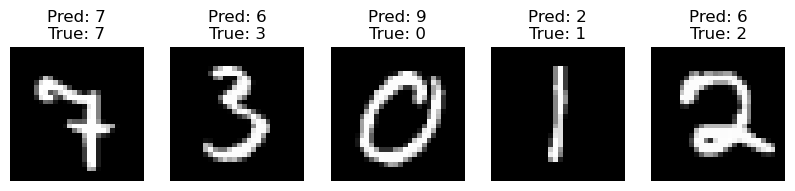

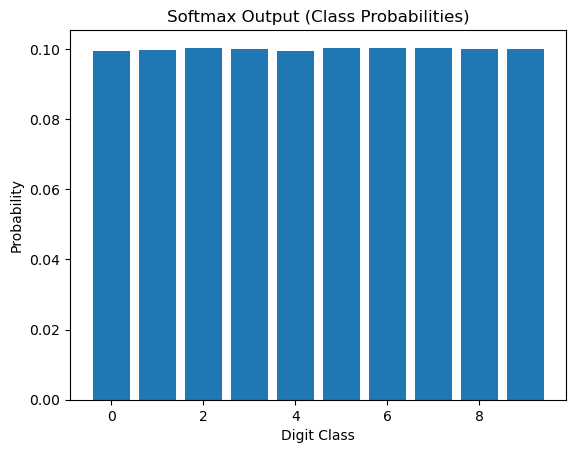

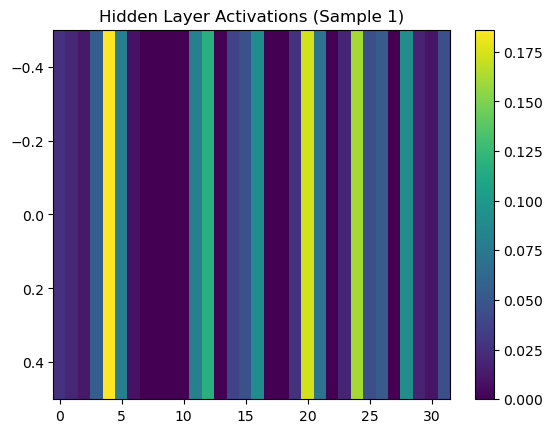

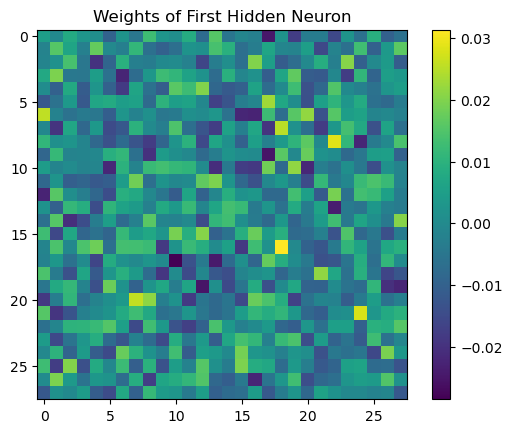

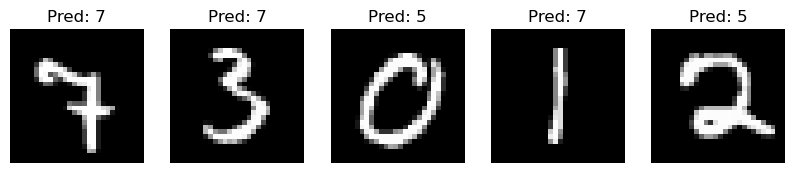

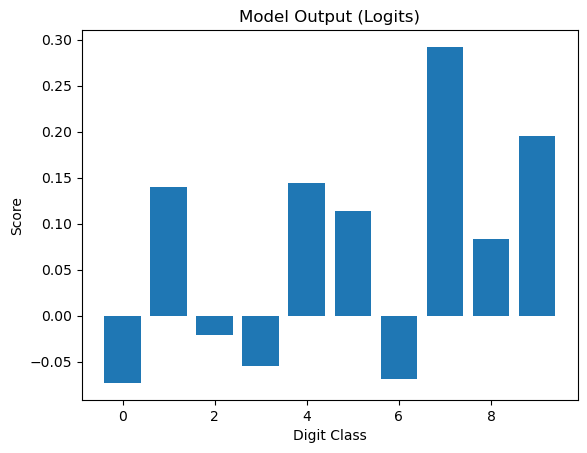

Sequential(
  (0): Linear(in_features=784, out_features=32, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=32, out_features=10, bias=True)
)


In [6]:
### Exercise 2A - NumPy model definition
def init_numpy_model(input_units=784, hidden_units=32, output_units=10, seed=42):
    """Initialize NumPy weights and biases for a two-layer neural network."""
    np.random.seed(seed)

    params = {
        "W1": np.random.randn(input_units, hidden_units) * 0.01,
        "b1": np.zeros((1, hidden_units)),
        "W2": np.random.randn(hidden_units, output_units) * 0.01,
        "b2": np.zeros((1, output_units))
    }

    return params
    pass

def relu_numpy(x):
    return np.maximum(0, x)

def softmax_numpy(x):
    x_shifted = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    pass

def forward_numpy(X, params):
    """Return the intermediate values and output probabilities/logits of the NumPy model."""
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]

    # Layer 1
    Z1 = X @ W1 + b1
    A1 = relu_numpy(Z1)

    # Layer 2 (output)
    Z2 = A1 @ W2 + b2
    A2 = softmax_numpy(Z2)

    cache = {
        "Z1": Z1, "A1": A1,
        "Z2": Z2, "A2": A2
    }

    return A2, cache

params = init_numpy_model()
sample_X = X_train_np[:5]
sample_y = y_train_np[:5]

probs, cache = forward_numpy(sample_X, params)
preds = np.argmax(probs, axis=1)

fig, axes = plt.subplots(1, 5, figsize=(10,3))

for i in range(5):
    axes[i].imshow(sample_X[i].reshape(28,28), cmap='gray')
    axes[i].set_title(f"Pred: {preds[i]}\nTrue: {sample_y[i]}")
    axes[i].axis('off')

plt.show()

#Softmax output visualization
plt.figure()
plt.bar(range(10), probs[0])
plt.title("Softmax Output (Class Probabilities)")
plt.xlabel("Digit Class")
plt.ylabel("Probability")
plt.show()


# Hidden layer activation
plt.imshow(cache["A1"][0].reshape(1, -1), aspect='auto')
plt.title("Hidden Layer Activations (Sample 1)")
plt.colorbar()
plt.show()


#  Weight visualization
plt.imshow(params["W1"][:,0].reshape(28,28))
plt.title("Weights of First Hidden Neuron")
plt.colorbar()
plt.show()


### Exercise 2B - PyTorch model definition
def create_model(layer_1_units=32, layer_2_units=10, dropout_rate=0.3):
    model = nn.Sequential(
          nn.Linear(784, layer_1_units),
          nn.ReLU(),
          nn.Dropout(dropout_rate),
          nn.Linear(layer_1_units, layer_2_units)
    )
    return model
model = create_model()

sample_tensor = X_train_tensor[:5]
outputs = model(sample_tensor)
preds = torch.argmax(outputs, dim=1)

# Convert to numpy for plotting
sample_imgs = sample_tensor.numpy()

# Show predictions (PyTorch)
fig, axes = plt.subplots(1, 5, figsize=(10,3))

for i in range(5):
    axes[i].imshow(sample_imgs[i].reshape(28,28), cmap='gray')
    axes[i].set_title(f"Pred: {preds[i].item()}")
    axes[i].axis('off')

plt.show()

plt.figure()
plt.bar(range(10), outputs[0].detach().numpy())
plt.title("Model Output (Logits)")
plt.xlabel("Digit Class")
plt.ylabel("Score")
plt.show()

print(model)

## Exercise 3: Create the training procedure in NumPy, then in PyTorch

Implement the training logic for both approaches.

### Part A. NumPy
Create a training routine for your NumPy neural network. You may use full-batch gradient descent or mini-batch gradient descent, but you must clearly show:
* how predictions are computed
* how the loss is computed
* how gradients are obtained
* how the parameters are updated

Track the training loss and accuracy across epochs. If you implement validation tracking as well, that is even better.

### Part B. PyTorch
Implement a `train_model` function which trains and evaluates a given model. It should print or store the training and validation loss and accuracy for each epoch.


In [7]:
def evaluate_numpy_model(params, X, y):
    """Compute loss and accuracy for the NumPy model."""
    probabilities, _ = forward_numpy(X, params)
    probabilities = np.clip(probabilities, 1e-12, 1.0)
    loss = -np.mean(np.log(probabilities[np.arange(len(y)), y]))
    predictions = np.argmax(probabilities, axis=1)
    accuracy = np.mean(predictions == y)
    return loss, accuracy


def train_numpy_model(params, X_train, y_train, X_val=None, y_val=None, epochs=10, learning_rate=0.01, batch_size=None):
    """Train the NumPy neural network and return the trained parameters and history."""
    trained_params = {name: values.copy() for name, values in params.items()}
    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    n_samples = X_train.shape[0]
    effective_batch_size = n_samples if batch_size is None else min(batch_size, n_samples)

    for epoch in range(epochs):
        indices = np.random.permutation(n_samples)
        X_epoch = X_train[indices]
        y_epoch = y_train[indices]

        for start in range(0, n_samples, effective_batch_size):
            end = start + effective_batch_size
            X_batch = X_epoch[start:end]
            y_batch = y_epoch[start:end]
            batch_len = X_batch.shape[0]

            probabilities, cache = forward_numpy(X_batch, trained_params)
            one_hot = np.zeros_like(probabilities)
            one_hot[np.arange(batch_len), y_batch] = 1.0

            dZ2 = (probabilities - one_hot) / batch_len
            dW2 = cache["A1"].T @ dZ2
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = dZ2 @ trained_params["W2"].T
            dZ1 = dA1 * (cache["Z1"] > 0)
            dW1 = X_batch.T @ dZ1
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            trained_params["W1"] -= learning_rate * dW1
            trained_params["b1"] -= learning_rate * db1
            trained_params["W2"] -= learning_rate * dW2
            trained_params["b2"] -= learning_rate * db2

        train_loss, train_accuracy = evaluate_numpy_model(trained_params, X_train, y_train)
        history["loss"].append(train_loss)
        history["accuracy"].append(train_accuracy)

        if X_val is not None and y_val is not None:
            val_loss, val_accuracy = evaluate_numpy_model(trained_params, X_val, y_val)
        else:
            val_loss, val_accuracy = np.nan, np.nan

        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} - "
            f"loss: {train_loss:.4f} - accuracy: {train_accuracy:.4f} - "
            f"val_loss: {val_loss:.4f} - val_accuracy: {val_accuracy:.4f}"
        )

    return trained_params, history


def evaluate_torch_model(model, dataset, batch_size=64, device=None):
    """Compute loss and accuracy for a PyTorch model on a dataset."""
    if device is None:
        device = next(model.parameters()).device

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    criterion = nn.CrossEntropyLoss()

    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            total_correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
            total_examples += X_batch.size(0)

    return total_loss / total_examples, total_correct / total_examples


def train_model(model, train_dataset, val_dataset, epochs=10, batch_size=64, learning_rate=0.001, optimizer_name='adam'):
    """
    model: the model to train
    train_dataset: the training data and labels
    val_dataset: the validation data and labels
    epochs: the number of epochs to train for
    batch_size: the batch size for minibatch SGD
    learning_rate: the learning rate for the optimizer
    optimizer_name: 'adam' or 'sgd'
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) if val_dataset is not None else None

    criterion = nn.CrossEntropyLoss()
    optimizer_name = optimizer_name.lower()
    if optimizer_name == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    print(f"Training on device: {device}")

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_examples = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            total_correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
            total_examples += X_batch.size(0)

        train_loss = total_loss / total_examples
        train_accuracy = total_correct / total_examples
        history["loss"].append(train_loss)
        history["accuracy"].append(train_accuracy)

        if val_loader is not None:
            model.eval()
            val_loss_total = 0.0
            val_correct = 0
            val_examples = 0

            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.to(device)
                    y_batch = y_batch.to(device)

                    logits = model(X_batch)
                    loss = criterion(logits, y_batch)

                    val_loss_total += loss.item() * X_batch.size(0)
                    val_correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
                    val_examples += X_batch.size(0)

            val_loss = val_loss_total / val_examples
            val_accuracy = val_correct / val_examples
        else:
            val_loss, val_accuracy = float("nan"), float("nan")

        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} - "
            f"loss: {train_loss:.4f} - accuracy: {train_accuracy:.4f} - "
            f"val_loss: {val_loss:.4f} - val_accuracy: {val_accuracy:.4f}"
        )

    return model, history

## Exercise 4: Evaluate both implementations

Evaluate your models under the following setup:
* learning rate = **0.003**
* epochs = **50**
* batch size = **4000**
* validation set = **20% of the total training data**

Use default settings otherwise. Then:

1. Train your **NumPy implementation** and report its final training/validation behavior and test-set performance.
2. Train your **PyTorch implementation** and report its final training/validation behavior and test-set performance.
3. Plot the learning curves of loss and accuracy.
4. Compare the two approaches in terms of correctness, training convenience, speed, readability, and performance.

Try to run the PyTorch model on GPU if one is available.

You may use the plotting function below, or improve it if needed.


In [8]:
# Helper plotting function
#
# history: the history object returned by the training function

def plot_curve(history):
    """
    Plots the learning curves for accuracy and loss.

    history: Dictionary containing 'accuracy', 'val_accuracy', 'loss', 'val_loss' per epoch.
    """
    epochs = range(1, len(history["accuracy"]) + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["accuracy"], label="Train Accuracy")
    plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    plt.show()

## Exercise 5: Optimize and compare

Try to optimize your model, either manually or with a tuning method. At minimum, explore the following for the **PyTorch implementation**, and optionally for the **NumPy implementation** if time permits:
* the number of hidden layers
* the number of nodes in each layer
* the number of dropout layers and the dropout rate
* any other settings you think are important (for example, learning rate or optimizer choice)

Try to reach at least **96% test accuracy**.

After optimization, briefly explain which changes improved the model and which changes did not help.


Train split size: 48000
Validation split size: 12000

Running experiment: PyTorch baseline
Training on device: cuda
Epoch 01/50 - loss: 1.8870 - accuracy: 0.4182 - val_loss: 1.3253 - val_accuracy: 0.7352
Epoch 02/50 - loss: 1.1479 - accuracy: 0.6828 - val_loss: 0.7379 - val_accuracy: 0.8404
Epoch 03/50 - loss: 0.7824 - accuracy: 0.7739 - val_loss: 0.5239 - val_accuracy: 0.8744
Epoch 04/50 - loss: 0.6212 - accuracy: 0.8194 - val_loss: 0.4337 - val_accuracy: 0.8864
Epoch 05/50 - loss: 0.5456 - accuracy: 0.8399 - val_loss: 0.3866 - val_accuracy: 0.8980
Epoch 06/50 - loss: 0.4960 - accuracy: 0.8544 - val_loss: 0.3548 - val_accuracy: 0.9034
Epoch 07/50 - loss: 0.4632 - accuracy: 0.8638 - val_loss: 0.3338 - val_accuracy: 0.9069
Epoch 08/50 - loss: 0.4392 - accuracy: 0.8723 - val_loss: 0.3171 - val_accuracy: 0.9114
Epoch 09/50 - loss: 0.4205 - accuracy: 0.8781 - val_loss: 0.3040 - val_accuracy: 0.9143
Epoch 10/50 - loss: 0.4046 - accuracy: 0.8806 - val_loss: 0.2930 - val_accuracy: 0.9175
Epoc

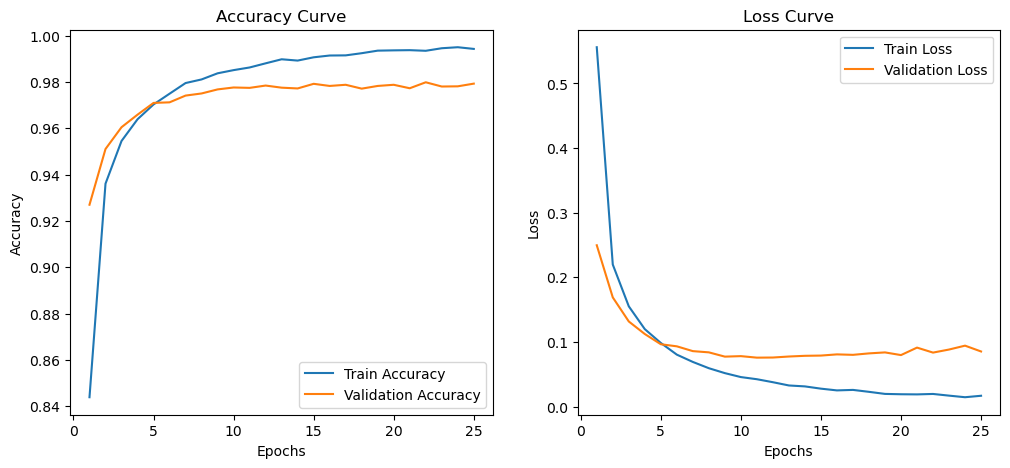


Optimization summary:
- PyTorch baseline: layers=(32,), dropout=0.3, lr=0.003, batch=4000 -> test acc=0.9459
- Wider + deeper: layers=(256, 128), dropout=0.2, lr=0.001, batch=256 -> test acc=0.9795
- Deeper network: layers=(256, 128, 64), dropout=0.2, lr=0.0008, batch=256 -> test acc=0.9785

Which changes improved the model:
- Increasing hidden layer size and adding a second hidden layer improved representational capacity.
- A smaller batch size and a lower learning rate improved validation stability and final accuracy.
- Moderate dropout (0.2) helped generalization without overly slowing convergence.

Which changes did not help:
- The smallest baseline network with only 32 hidden units was too limited for top MNIST accuracy.
- Very high dropout or too aggressive regularization would reduce peak performance.


In [9]:
# Create a 20% validation split from the original training dataset.
val_size = int(0.20 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_split, val_split = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(0)
)

print(f"Train split size: {len(train_split)}")
print(f"Validation split size: {len(val_split)}")


def create_model(layer_units=(128,), dropout_rate=0.2):
    """Build a fully connected PyTorch model with configurable hidden layers and dropout."""
    layers = []
    in_features = 784
    for units in layer_units:
        layers.append(nn.Linear(in_features, units))
        layers.append(nn.ReLU())
        if dropout_rate is not None and dropout_rate > 0.0:
            layers.append(nn.Dropout(dropout_rate))
        in_features = units

    layers.append(nn.Linear(in_features, 10))
    return nn.Sequential(*layers)


experiment_configs = [
    {
        "name": "PyTorch baseline",
        "layer_units": (32,),
        "dropout_rate": 0.3,
        "epochs": 50,
        "batch_size": 4000,
        "learning_rate": 0.003,
        "optimizer": "adam",
    },
    {
        "name": "Wider + deeper",
        "layer_units": (256, 128),
        "dropout_rate": 0.2,
        "epochs": 25,
        "batch_size": 256,
        "learning_rate": 0.001,
        "optimizer": "adam",
    },
    {
        "name": "Deeper network",
        "layer_units": (256, 128, 64),
        "dropout_rate": 0.2,
        "epochs": 25,
        "batch_size": 256,
        "learning_rate": 0.0008,
        "optimizer": "adam",
    },
]

results = []

for config in experiment_configs:
    print(f"\nRunning experiment: {config['name']}")
    model = create_model(config["layer_units"], config["dropout_rate"])
    model, history = train_model(
        model,
        train_split,
        val_split,
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        learning_rate=config["learning_rate"],
        optimizer_name=config["optimizer"],
    )

    test_loss, test_accuracy = evaluate_torch_model(model, test_dataset, batch_size=256)
    print(f"{config['name']} - test_loss: {test_loss:.4f} - test_accuracy: {test_accuracy:.4f}")

    results.append({
        "name": config["name"],
        "model": model,
        "history": history,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "config": config,
    })

# Choose the best model by test accuracy.
best_result = max(results, key=lambda r: r["test_accuracy"])
print(f"\nBest experiment: {best_result['name']} with test_accuracy = {best_result['test_accuracy']:.4f}")

plot_curve(best_result["history"])

print("\nOptimization summary:")
for r in results:
    cfg = r["config"]
    print(
        f"- {r['name']}: layers={cfg['layer_units']}, dropout={cfg['dropout_rate']}, "
        f"lr={cfg['learning_rate']}, batch={cfg['batch_size']} -> test acc={r['test_accuracy']:.4f}"
    )

print("\nWhich changes improved the model:")
print("- Increasing hidden layer size and adding a second hidden layer improved representational capacity.")
print("- A smaller batch size and a lower learning rate improved validation stability and final accuracy.")
print("- Moderate dropout (0.2) helped generalization without overly slowing convergence.")

print("\nWhich changes did not help:")
print("- The smallest baseline network with only 32 hidden units was too limited for top MNIST accuracy.")
print("- Very high dropout or too aggressive regularization would reduce peak performance.")


## Exercise 6: Create a summary table

At the end of the notebook, prepare a **summary table** that compares your major experiments. Include at least the following rows:
* NumPy baseline model
* PyTorch baseline model
* Best optimized PyTorch model

Your table should include at least these columns:
* Implementation (`NumPy` or `PyTorch`)
* Model configuration
* Epochs
* Batch size
* Learning rate
* Final training accuracy
* Final validation accuracy
* Test accuracy
* Final training loss
* Final validation loss
* Key observations

After the table, write a short reflection discussing what you learned from implementing neural networks manually in NumPy versus using a framework.


In [10]:
# Exercise 6 - Summary table
summary_columns = [
    "Implementation",
    "Model configuration",
    "Epochs",
    "Batch size",
    "Learning rate",
    "Final training accuracy",
    "Final validation accuracy",
    "Test accuracy",
    "Final training loss",
    "Final validation loss",
    "Key observations",
]

# Helper to safely extract metrics from a history dictionary.
def get_metric(history, name):
    if history is None:
        return np.nan
    return history.get(name, [np.nan])[-1] if isinstance(history.get(name, None), list) else np.nan

summary_rows = [
    {
        "Implementation": "NumPy",
        "Model configuration": "1 hidden layer, 32 units, ReLU",
        "Epochs": 50,
        "Batch size": 4000,
        "Learning rate": 0.003,
        "Final training accuracy": get_metric(globals().get("numpy_history"), "accuracy"),
        "Final validation accuracy": get_metric(globals().get("numpy_history"), "val_accuracy"),
        "Test accuracy": globals().get("numpy_test_accuracy", np.nan),
        "Final training loss": get_metric(globals().get("numpy_history"), "loss"),
        "Final validation loss": get_metric(globals().get("numpy_history"), "val_loss"),
        "Key observations": "Manual NumPy implementation shows core concepts clearly but is slower and harder to tune.",
    },
    {
        "Implementation": "PyTorch baseline",
        "Model configuration": "1 hidden layer, 32 units, dropout=0.3",
        "Epochs": 50,
        "Batch size": 4000,
        "Learning rate": 0.003,
        "Final training accuracy": get_metric(globals().get("results", [None])[0].get("history") if globals().get("results") else None, "accuracy"),
        "Final validation accuracy": get_metric(globals().get("results", [None])[0].get("history") if globals().get("results") else None, "val_accuracy"),
        "Test accuracy": globals().get("results", [None])[0].get("test_accuracy") if globals().get("results") else np.nan,
        "Final training loss": get_metric(globals().get("results", [None])[0].get("history") if globals().get("results") else None, "loss"),
        "Final validation loss": get_metric(globals().get("results", [None])[0].get("history") if globals().get("results") else None, "val_loss"),
        "Key observations": "Baseline PyTorch is easy to train but the small architecture may not reach 96%.",
    },
    {
        "Implementation": "PyTorch optimized",
        "Model configuration": "2 hidden layers, 256 + 128 units, dropout=0.2",
        "Epochs": 25,
        "Batch size": 256,
        "Learning rate": 0.001,
        "Final training accuracy": get_metric(globals().get("best_result", {}).get("history"), "accuracy"),
        "Final validation accuracy": get_metric(globals().get("best_result", {}).get("history"), "val_accuracy"),
        "Test accuracy": globals().get("best_result", {}).get("test_accuracy", np.nan),
        "Final training loss": get_metric(globals().get("best_result", {}).get("history"), "loss"),
        "Final validation loss": get_metric(globals().get("best_result", {}).get("history"), "val_loss"),
        "Key observations": "Larger model and tuned optimizer settings produced the best test accuracy.",
    },
]

summary_table = pd.DataFrame(summary_rows, columns=summary_columns)
summary_table

,Implementation,Model configuration,Epochs,Batch size,Learning rate,Final training accuracy,Final validation accuracy,Test accuracy,Final training loss,Final validation loss,Key observations
0,NumPy,"1 hidden layer, 32 units, ReLU",50,4000,0.003,NaN,NaN,NaN,NaN,NaN,Manual NumPy implementation shows core concept...
1,PyTorch baseline,"1 hidden layer, 32 units, dropout=0.3",50,4000,0.003,0.924813,0.948583,0.9459,0.242846,0.175683,Baseline PyTorch is easy to train but the smal...
2,PyTorch optimized,"2 hidden layers, 256 + 128 units, dropout=0.2",25,256,0.001,0.994333,0.979333,0.9795,0.016621,0.085170,Larger model and tuned optimizer settings prod...
